<a href="https://colab.research.google.com/github/RafihaikalP/BigData26_A_2411532002_Rafi-Haikal-Pratama/blob/main/Praktikum4/BD_P04_Tugas_2411532002_Rafi_Haikal_Pratama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum 4 — NoSQL dan Pemodelan Data


## Persiapan

In [ ]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"

Mounted at /content/drive


In [ ]:
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.6 MB/s eta 0:00:00


In [ ]:
import os, time, json, sqlite3, shutil, glob
import numpy as np, pandas as pd

DIR_TUGAS = f"{DIR_SIMPAN}/Tugas"
os.makedirs(DIR_TUGAS, exist_ok=True)
assert os.path.exists(TRIPS_BERSIH), "Folder trips_bersih/ tidak ada. Jalankan ulang P3/K-10 atau pakai K-1b pada notebook utama."

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

catatan_tugas = []
def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan_tugas.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil

NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput", "PULocationID": "zona_jemput", "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput", "trip_distance": "jarak_mil", "total_amount": "total_bayar",
    "tip_amount": "tip", "nama_pembayaran": "metode_bayar",
}
df = pd.read_parquet(TRIPS_BERSIH, engine="fastparquet").rename(columns=NAMA_BARU)
df["wilayah_jemput"] = df["wilayah_jemput"].astype(str)
print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])

baris: 2,986,910 | kolom: 18


# R.1 Rekap Benchmark


In [ ]:
BENCH = f"{DIR_SIMPAN}/benchmark_nosql.csv"
assert os.path.exists(BENCH), "benchmark_nosql.csv tidak ditemukan. Jalankan notebook utama sampai K-9."
bench = pd.read_csv(BENCH)
print(bench.to_string(index=False))

def w(label):
    return float(bench.loc[bench["langkah"] == label, "detik"].iloc[-1])

def x(a, b):
    return a / b if b else float("nan")

                                            langkah   detik
                                  baca_trips_bersih 11.5381
                             relasional: muat tabel  1.4520
                             key-value: bangun dict  4.2014
             cari 200 perjalanan - SQL tanpa indeks  4.1811
            cari 200 perjalanan - SQL dengan indeks  0.0037
                    cari 200 perjalanan - key-value  0.0011
                  hitung per wilayah - SQL GROUP BY  0.1820
  hitung per wilayah - key-value (buka semua nilai)  1.2387
DuckDB - hitung per wilayah (langsung dari Parquet)  0.2272
               SQLite - muat seluruh baris ke tabel  9.5751
                        SQLite - hitung per wilayah  1.7270
               DuckDB - hanya wilayah Staten Island  0.0419
                             hitung arus antar zona  0.5069
                       2 langkah - graph (NetworkX)  0.0065
                 2 langkah - SQL self-join (DuckDB)  0.0142
                      cara 1 - loop Pyth

In [ ]:
loop_1000 = w("cara 1 - loop Python, 5 kotak") / 5 * 1000     # perkiraan, tidak dijalankan
strtree_total = w("bangun indeks STRtree") + w("cara 3 - STRtree, 1000 kotak")
numpy_s = w("cara 2 - NumPy, 1000 kotak")

r_idx = x(w("cari 200 perjalanan - SQL tanpa indeks"), w("cari 200 perjalanan - SQL dengan indeks"))
r_kv = x(w("cari 200 perjalanan - SQL dengan indeks"), w("cari 200 perjalanan - key-value"))
r_duck = x(w("SQLite - hitung per wilayah"), w("DuckDB - hitung per wilayah (langsung dari Parquet)"))
r_hit = x(w("hitung per wilayah - key-value (buka semua nilai)"), w("hitung per wilayah - SQL GROUP BY"))
g_s, s_s = w("2 langkah - graph (NetworkX)"), w("2 langkah - SQL self-join (DuckDB)")

rekap_k9 = pd.DataFrame([
    ["Ambil satu data lewat id", "Key-value; tabel dengan indeks", "Tabel tanpa indeks",
     f"tanpa indeks {w('cari 200 perjalanan - SQL tanpa indeks'):.4f} s | berindeks {w('cari 200 perjalanan - SQL dengan indeks'):.4f} s | key-value {w('cari 200 perjalanan - key-value'):.4f} s"],
    ["Menghitung atau merangkum banyak baris", "Per kolom (DuckDB pada Parquet)", "Key-value (buka semua nilai)",
     f"DuckDB {w('DuckDB - hitung per wilayah (langsung dari Parquet)'):.4f} s | SQLite {w('SQLite - hitung per wilayah'):.4f} s | SQL GROUP BY {w('hitung per wilayah - SQL GROUP BY'):.4f} s | key-value {w('hitung per wilayah - key-value (buka semua nilai)'):.4f} s"],
    ["Data dengan field opsional atau berubah-ubah", "Document", "Tabel (kolom NULL, migrasi)", "(kualitatif)"],
    ["Keterhubungan dengan jumlah langkah bebas", "Graph", "SQL (satu JOIN per langkah)",
     f"2 langkah: graph {g_s:.4f} s | SQL self-join {s_s:.4f} s"],
    ["Mencari lokasi dalam wilayah", "Spasial dengan indeks", "Memeriksa semua titik",
     f"STRtree (bangun+cari) {strtree_total:.4f} s | NumPy {numpy_s:.4f} s | loop Python ~{loop_1000:.0f} s (perkiraan)"],
    ["Perubahan yang harus aman dan bisa dibatalkan", "Tabel Delta", "Folder Parquet biasa", "(kualitatif)"],
], columns=["Kebutuhan", "Cara yang unggul", "Cara yang lemah", "Angka Anda"])

# DRAF interpretasi (satu kalimat per baris) - UBAH dengan kata-kata Anda sendiri
rekap_k9["Interpretasi (1 kalimat)"] = [
    f"Mencari satu id pada tabel tanpa indeks {r_idx:.0f}x lebih lambat daripada tabel berindeks karena baris diperiksa satu per satu, dan setelah diberi indeks tabel hanya {r_kv:.1f}x lebih lambat dari key-value.",
    f"DuckDB {r_duck:.1f}x lebih cepat dari SQLite karena hanya membaca kolom yang dibutuhkan dan memproses banyak baris sekaligus, sedangkan key-value {r_hit:.1f}x lebih lambat dari SQL GROUP BY karena setiap nilai harus dibuka dulu.",
    "Dokumen boleh membawa field berbeda tanpa migrasi (mis. field tip dan cuaca), tetapi salah ketik nama field tidak ditegur database karena tidak ada skema.",
    f"Waktu dua langkah graph {g_s:.4f} s dan SQL self-join {s_s:.4f} s pada 263 zona; nilai tambah graph ada pada cara bertanya (ganti angka k) dan bukan pada kecepatan semata.",
    f"STRtree {x(numpy_s, strtree_total):.1f}x lebih cepat dari NumPy tetapi sekitar {x(loop_1000, strtree_total):.0f}x dari loop Python (perkiraan), jadi besar keuntungan indeks bergantung pada pembanding (titik adalah data tiruan).",
    "Delta Lake mencatat tiap perubahan di _delta_log sehingga versi lama bisa dibaca dan data bukan skema ditolak, sedangkan folder Parquet biasa tidak punya jaminan itu.",
]
display(rekap_k9)

rekap_k9.to_csv(f"{DIR_TUGAS}/rekap_k9_terisi.csv", index=False)
print("tersimpan:", f"{DIR_TUGAS}/rekap_k9_terisi.csv")

,Kebutuhan,Cara yang unggul,Cara yang lemah,Angka Anda,Interpretasi (1 kalimat)
0,Ambil satu data lewat id,Key-value; tabel dengan indeks,Tabel tanpa indeks,tanpa indeks 4.1811 s | berindeks 0.0037 s | key-value 0.0011 s,"Mencari satu id pada tabel tanpa indeks 1130x lebih lambat daripada tabel berindeks karena baris diperiksa satu per satu, dan setelah diberi indeks tabel hanya 3.4x lebih lambat dari key-value."
1,Menghitung atau merangkum banyak baris,Per kolom (DuckDB pada Parquet),Key-value (buka semua nilai),DuckDB 0.2272 s | SQLite 1.7270 s | SQL GROUP BY 0.1820 s | key-value 1.2387 s,"DuckDB 7.6x lebih cepat dari SQLite karena hanya membaca kolom yang dibutuhkan dan memproses banyak baris sekaligus, sedangkan key-value 6.8x lebih lambat dari SQL GROUP BY karena setiap nilai harus dibuka dulu."
2,Data dengan field opsional atau berubah-ubah,Document,"Tabel (kolom NULL, migrasi)",(kualitatif),"Dokumen boleh membawa field berbeda tanpa migrasi (mis. field tip dan cuaca), tetapi salah ketik nama field tidak ditegur database karena tidak ada skema."
3,Keterhubungan dengan jumlah langkah bebas,Graph,SQL (satu JOIN per langkah),2 langkah: graph 0.0065 s | SQL self-join 0.0142 s,Waktu dua langkah graph 0.0065 s dan SQL self-join 0.0142 s pada 263 zona; nilai tambah graph ada pada cara bertanya (ganti angka k) dan bukan pada kecepatan semata.
4,Mencari lokasi dalam wilayah,Spasial dengan indeks,Memeriksa semua titik,STRtree (bangun+cari) 0.2392 s | NumPy 0.4990 s | loop Python ~2605 s (perkiraan),"STRtree 2.1x lebih cepat dari NumPy tetapi sekitar 10891x dari loop Python (perkiraan), jadi besar keuntungan indeks bergantung pada pembanding (titik adalah data tiruan)."
5,Perubahan yang harus aman dan bisa dibatalkan,Tabel Delta,Folder Parquet biasa,(kualitatif),"Delta Lake mencatat tiap perubahan di _delta_log sehingga versi lama bisa dibaca dan data bukan skema ditolak, sedangkan folder Parquet biasa tidak punya jaminan itu."


tersimpan: /content/drive/MyDrive/BigData/Praktikum4/Tugas/rekap_k9_terisi.csv


**Catatan R.1.** Sebelum dikumpulkan, periksa tiap kalimat interpretasi di atas: satu klaim, satu angka, satu alasan. Ubah bagian yang tidak sesuai dengan hasil Anda (mis. bila graph ternyata lebih lambat/lebih cepat dari SQL di komputer Anda). Kumpulkan `benchmark_nosql.csv` dan `rekap_k9_terisi.csv`.

# R.2 Data Lain, Cara Lain
Data yang dipilih: **"zona"** (263 zona taksi). Tiga cara menyimpannya:

| Model | Bentuk penyimpanan | Pertanyaan **mudah** | Pertanyaan **canggung** |
|---|---|---|---|
| Tabel (SQLite) | tabel `zona_tbl` (ringkasan zona) + `arus_tbl` (zona asal, zona tujuan, jumlah) | rata-rata total bayar per wilayah | zona yang dicapai dalam **tepat 3 langkah** (dua self-join) |
| Document (TinyDB) | satu dokumen per zona, memuat ringkasan dan 5 tujuan teratas (embedding) | tampilkan satu zona utuh beserta 5 tujuan teratasnya | "zona asal mana saja yang memuat zona X di 5 tujuan teratasnya" (harus memeriksa semua dokumen) |
| Graph (NetworkX) | node = zona (dengan atribut), edge = arus berbobot | zona yang dicapai dalam **tepat 3 langkah** | rata-rata total bayar per wilayah (harus ditulis sendiri lewat loop atribut node) |

In [ ]:
import duckdb, networkx as nx
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage

GLOB = f"{TRIPS_BERSIH}/*/*.parquet"
con_d = duckdb.connect()
con_d.sql(f"""
    CREATE VIEW perjalanan AS
    SELECT tpep_pickup_datetime AS waktu_jemput, PULocationID AS zona_jemput, DOLocationID AS zona_tujuan,
           borough_naik AS wilayah_jemput, trip_distance AS jarak_mil, total_amount AS total_bayar,
           nama_pembayaran AS metode_bayar
    FROM read_parquet('{GLOB}', hive_partitioning=true)""")

# Ringkasan per zona jemput, arus antar zona, dan 5 tujuan teratas per zona
zona_df = con_d.sql("""
    SELECT zona_jemput AS zona, ANY_VALUE(wilayah_jemput) AS wilayah, COUNT(*) AS jumlah_jemput,
           ROUND(AVG(total_bayar), 2) AS rata_bayar, ROUND(AVG(jarak_mil), 2) AS rata_jarak
    FROM perjalanan GROUP BY 1 ORDER BY 1""").df()
arus = con_d.sql("""
    SELECT zona_jemput AS asal, zona_tujuan AS tujuan, COUNT(*) AS jumlah
    FROM perjalanan GROUP BY 1, 2""").df()
con_d.register("arus_df", arus)
top5 = con_d.sql("""
    SELECT asal, tujuan, jumlah FROM (
        SELECT asal, tujuan, jumlah,
               ROW_NUMBER() OVER (PARTITION BY asal ORDER BY jumlah DESC, tujuan) AS rn
        FROM arus_df) WHERE rn <= 5 ORDER BY asal, jumlah DESC, tujuan""").df()
print("zona:", len(zona_df), "| arus:", len(arus), "| baris top5:", len(top5))

MIN = 50   # abaikan arus yang kurang dari 50 perjalanan (sama seperti K-5)
ZONA_AWAL = int(zona_df.sort_values(["jumlah_jemput", "zona"], ascending=[False, True]).iloc[0]["zona"])
ZONA_X = int(arus.groupby("tujuan")["jumlah"].sum().sort_values(ascending=False).index[0])
print("zona awal (jemput terbanyak):", ZONA_AWAL, "| zona X (tujuan terpopuler):", ZONA_X)

zona: 254 | arus: 21583 | baris top5: 1218
zona awal (jemput terbanyak): 132 | zona X (tujuan terpopuler): 236


### Model 1: Tabel (SQLite)

In [ ]:
con_t = sqlite3.connect(":memory:")
zona_df.to_sql("zona_tbl", con_t, index=False)
arus.to_sql("arus_tbl", con_t, index=False)
con_t.execute("CREATE INDEX idx_arus_asal ON arus_tbl(asal)")      # indeks yang wajar untuk join

def tabel_mudah():
    return con_t.execute("""SELECT wilayah, SUM(jumlah_jemput) AS jemput,
                                   ROUND(SUM(jumlah_jemput * rata_bayar) * 1.0 / SUM(jumlah_jemput), 2) AS rata_bayar
                            FROM zona_tbl GROUP BY wilayah ORDER BY jemput DESC, wilayah""").fetchall()

def tabel_canggung():
    return {r[0] for r in con_t.execute(f"""
        SELECT DISTINCT a3.tujuan
        FROM arus_tbl a1
        JOIN arus_tbl a2 ON a1.tujuan = a2.asal
        JOIN arus_tbl a3 ON a2.tujuan = a3.asal
        WHERE a1.asal = {ZONA_AWAL} AND a1.jumlah >= {MIN} AND a2.jumlah >= {MIN} AND a3.jumlah >= {MIN}""").fetchall()}

h_tm = ukur("R2 tabel - MUDAH: rata-rata bayar per wilayah", tabel_mudah)
h_tc = ukur("R2 tabel - CANGGUNG: tepat 3 langkah (2 self-join)", tabel_canggung)
print(h_tm[:3]); print("zona terjangkau (tepat 3 langkah):", len(h_tc))

[R2 tabel - MUDAH: rata-rata bayar per wilayah] 0.0004 s
[R2 tabel - CANGGUNG: tepat 3 langkah (2 self-join)] 0.4773 s
[('Manhattan', 2659609, 22.72), ('Queens', 270315, 70.46), ('Unknown', 37609, 39.24)]
zona terjangkau (tepat 3 langkah): 215


### Model 2: Document (TinyDB)

In [ ]:
db = TinyDB(storage=MemoryStorage)
tabel_dok = db.table("zona")
top_per_zona = top5.groupby("asal")
dokumen = []
for r in zona_df.itertuples(index=False):
    t = top_per_zona.get_group(r.zona) if r.zona in top_per_zona.groups else top5.iloc[0:0]
    dokumen.append({"zona": int(r.zona), "wilayah": r.wilayah, "jumlah_jemput": int(r.jumlah_jemput),
                    "rata_bayar": float(r.rata_bayar), "rata_jarak": float(r.rata_jarak),
                    "top_tujuan": [{"zona": int(a), "jumlah": int(b)} for a, b in zip(t["tujuan"], t["jumlah"])]})
tabel_dok.insert_multiple(dokumen)
Q = Query()
print("jumlah dokumen:", len(tabel_dok))
print(json.dumps(tabel_dok.get(Q.zona == ZONA_AWAL), indent=2))

def dok_mudah():
    return tabel_dok.get(Q.zona == ZONA_AWAL)

def dok_canggung():
    return sorted(d["zona"] for d in tabel_dok.search(Q.top_tujuan.test(lambda lst: any(t["zona"] == ZONA_X for t in lst))))

h_dm = ukur("R2 document - MUDAH: ambil satu zona utuh", dok_mudah)
h_dc = ukur("R2 document - CANGGUNG: zona yang memuat X di top-5 tujuan", dok_canggung)

# Silangkan dengan SQL (DuckDB) agar yakin jawabannya sama
cek_sql = sorted(con_d.sql(f"SELECT asal FROM top5 WHERE tujuan = {ZONA_X}").df()["asal"].tolist())
print("zona asal yang memuat zona", ZONA_X, "di top-5:", len(h_dc), "| sama dengan SQL?", h_dc == cek_sql)

jumlah dokumen: 254
{
  "zona": 132,
  "wilayah": "Queens",
  "jumlah_jemput": 152840,
  "rata_bayar": 77.33,
  "rata_jarak": 15.6,
  "top_tujuan": [
    {
      "zona": 230,
      "jumlah": 5835
    },
    {
      "zona": 265,
      "jumlah": 4942
    },
    {
      "zona": 48,
      "jumlah": 3945
    },
    {
      "zona": 10,
      "jumlah": 3397
    },
    {
      "zona": 93,
      "jumlah": 3141
    }
  ]
}
[R2 document - MUDAH: ambil satu zona utuh] 0.0001 s
[R2 document - CANGGUNG: zona yang memuat X di top-5 tujuan] 0.0005 s
zona asal yang memuat zona 236 di top-5: 23 | sama dengan SQL? True


### Model 3: Graph (NetworkX)

In [ ]:
G = nx.DiGraph()
for r in zona_df.itertuples(index=False):
    G.add_node(int(r.zona), wilayah=r.wilayah, jumlah_jemput=int(r.jumlah_jemput), rata_bayar=float(r.rata_bayar))
for r in arus.itertuples(index=False):
    G.add_edge(int(r.asal), int(r.tujuan), jumlah=int(r.jumlah))
H = nx.DiGraph([(a, b) for a, b, d in G.edges(data=True) if d["jumlah"] >= MIN])
print("node:", G.number_of_nodes(), "| edge:", G.number_of_edges(), "| edge >= MIN:", H.number_of_edges())

def graph_mudah():           # tepat 3 langkah berturut-turut (boleh kembali ke zona sebelumnya)
    f = {ZONA_AWAL}
    for _ in range(3):
        f = {c for b in f if b in H for c in H.successors(b)}
    return f

def graph_canggung():
    jml, total = {}, {}
    for _, a in G.nodes(data=True):
        # Lewati node yang tidak memiliki atribut 'wilayah'
        if "wilayah" not in a:
            continue

        w = a["wilayah"]
        jml[w] = jml.get(w, 0) + a["jumlah_jemput"]
        total[w] = total.get(w, 0) + a["jumlah_jemput"] * a["rata_bayar"]

    return sorted([(w, jml[w], round(total[w] / jml[w], 2)) for w in jml], key=lambda t: (-t[1], t[0]))

h_gm = ukur("R2 graph - MUDAH: tepat 3 langkah", graph_mudah)
h_gc = ukur("R2 graph - CANGGUNG: rata-rata bayar per wilayah", graph_canggung)
print("zona terjangkau (tepat 3 langkah) graph:", len(h_gm), "| sama dengan tabel (2 self-join)?", h_gm == h_tc)
print("rata-rata per wilayah (graph) :", h_gc[:3])
print("rata-rata per wilayah (tabel) :", [tuple(r) for r in h_tm[:3]])

node: 262 | edge: 21583 | edge >= MIN: 4122
[R2 graph - MUDAH: tepat 3 langkah] 0.0072 s
[R2 graph - CANGGUNG: rata-rata bayar per wilayah] 0.0004 s
zona terjangkau (tepat 3 langkah) graph: 215 | sama dengan tabel (2 self-join)? True
rata-rata per wilayah (graph) : [('Manhattan', 2659609, 22.72), ('Queens', 270315, 70.46), ('Unknown', 37609, 39.24)]
rata-rata per wilayah (tabel) : [('Manhattan', 2659609, 22.72), ('Queens', 270315, 70.46), ('Unknown', 37609, 39.24)]


In [ ]:
# Tabel rancangan R.2 (kolom waktu diisi dari hasil ukur Anda)
def t(label):
    return next(c["detik"] for c in reversed(catatan_tugas) if c["langkah"] == label)

rancangan = pd.DataFrame([
    ["Tabel (SQLite)", "zona_tbl + arus_tbl (diberi indeks pada asal)",
     "Rata-rata total bayar per wilayah (GROUP BY)", t("R2 tabel - MUDAH: rata-rata bayar per wilayah"),
     "Zona yang dicapai dalam tepat 3 langkah", t("R2 tabel - CANGGUNG: tepat 3 langkah (2 self-join)"),
     "Satu JOIN tambahan untuk setiap langkah; 'k langkah bebas' berarti menulis ulang query."],
    ["Document (TinyDB)", "1 dokumen per zona, 5 tujuan teratas tertanam (embedding)",
     "Tampilkan satu zona utuh beserta 5 tujuan teratasnya", t("R2 document - MUDAH: ambil satu zona utuh"),
     "Zona asal mana saja yang memuat zona X di 5 tujuan teratasnya", t("R2 document - CANGGUNG: zona yang memuat X di top-5 tujuan"),
     "Arah pencarian dibalik dari arah penyimpanan: semua dokumen harus diperiksa; data tujuan juga terduplikasi."],
    ["Graph (NetworkX)", "node = zona (atribut wilayah, jumlah, rata bayar), edge = arus berbobot",
     "Zona yang dicapai dalam tepat 3 langkah", t("R2 graph - MUDAH: tepat 3 langkah"),
     "Rata-rata total bayar per wilayah", t("R2 graph - CANGGUNG: rata-rata bayar per wilayah"),
     "Graph tidak dirancang untuk merangkum atribut; agregasi ditulis sendiri lewat loop."],
], columns=["Model", "Bentuk penyimpanan", "Pertanyaan MUDAH", "Waktu mudah (s)",
            "Pertanyaan CANGGUNG", "Waktu canggung (s)", "Mengapa canggung"])
display(rancangan)
rancangan.to_csv(f"{DIR_TUGAS}/rancangan_data_lain.csv", index=False)

,Model,Bentuk penyimpanan,Pertanyaan MUDAH,Waktu mudah (s),Pertanyaan CANGGUNG,Waktu canggung (s),Mengapa canggung
0,Tabel (SQLite),zona_tbl + arus_tbl (diberi indeks pada asal),Rata-rata total bayar per wilayah (GROUP BY),0.0004,Zona yang dicapai dalam tepat 3 langkah,0.4773,Satu JOIN tambahan untuk setiap langkah; 'k langkah bebas' berarti menulis ulang query.
1,Document (TinyDB),"1 dokumen per zona, 5 tujuan teratas tertanam (embedding)",Tampilkan satu zona utuh beserta 5 tujuan teratasnya,0.0001,Zona asal mana saja yang memuat zona X di 5 tujuan teratasnya,0.0005,Arah pencarian dibalik dari arah penyimpanan: semua dokumen harus diperiksa; data tujuan juga terduplikasi.
2,Graph (NetworkX),"node = zona (atribut wilayah, jumlah, rata bayar), edge = arus berbobot",Zona yang dicapai dalam tepat 3 langkah,0.0072,Rata-rata total bayar per wilayah,0.0004,Graph tidak dirancang untuk merangkum atribut; agregasi ditulis sendiri lewat loop.


# R.3 Delta Lake Dua Hari


In [ ]:
import os
import shutil
from deltalake import DeltaTable, write_deltalake

KOLOM_DELTA = ["waktu_jemput", "zona_jemput", "zona_tujuan", "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data_d = df[KOLOM_DELTA].sample(n=min(120_000, len(df)), random_state=7).reset_index(drop=True)

# GANTI: Gunakan jalur lokal Colab (/content/...) untuk pemprosesan Delta Lake
PATH_2HARI_LOCAL = "/content/trips_delta_dua_hari"
PATH_2HARI_DRIVE = f"{DIR_TUGAS}/trips_delta_dua_hari"

if os.path.exists(PATH_2HARI_LOCAL):
    shutil.rmtree(PATH_2HARI_LOCAL)

# ================= HARI 1: menulis sebagian data =================
write_deltalake(PATH_2HARI_LOCAL, data_d.iloc[:40_000], mode="overwrite")  # versi 0
write_deltalake(PATH_2HARI_LOCAL, data_d.iloc[40_000:60_000], mode="append")  # versi 1

dt = DeltaTable(PATH_2HARI_LOCAL)
VERSI_AKHIR_HARI1 = dt.version()
akhir_h1 = dt.to_pandas()
cat_h1 = {
    "versi": VERSI_AKHIR_HARI1,
    "baris": len(akhir_h1),
    "sum_total_bayar": round(float(akhir_h1["total_bayar"].sum()), 2)
}
print("AKHIR HARI 1 ->", cat_h1)

# OPTIONAL: Salin ke Google Drive setelah proses selesai
if os.path.exists(PATH_2HARI_DRIVE):
    shutil.rmtree(PATH_2HARI_DRIVE)
shutil.copytree(PATH_2HARI_LOCAL, PATH_2HARI_DRIVE)
print("Berhasil menyalin ke Google Drive!")

AKHIR HARI 1 -> {'versi': 1, 'baris': 60000, 'sum_total_bayar': 1638407.97}
Berhasil menyalin ke Google Drive!


In [ ]:
# Gunakan jalur lokal VM Colab untuk operasi Delta Lake
PATH_2HARI = "/content/trips_delta_dua_hari"

# ================= HARI 2: tambah data + koreksi =================
write_deltalake(PATH_2HARI, data_d.iloc[60_000:90_000], mode="append")  # versi 2 (data baru)

dt = DeltaTable(PATH_2HARI)
sebelum_koreksi = dt.to_pandas()
n_koreksi2 = int(((sebelum_koreksi["wilayah_jemput"] == "Queens") & (sebelum_koreksi["metode_bayar"] == "Tunai")).sum())

dt.update(
    predicate="wilayah_jemput = 'Queens' AND metode_bayar = 'Tunai'",
    updates={"total_bayar": "total_bayar + 0.5"}
)  # versi 3 (koreksi tarif)

dt = DeltaTable(PATH_2HARI)
akhir_h2 = dt.to_pandas()

print(f"AKHIR HARI 2 -> versi: {dt.version()} | baris: {len(akhir_h2)} | sum total_bayar: {round(float(akhir_h2['total_bayar'].sum()), 2)} | baris dikoreksi: {n_koreksi2}")
print(f"selisih total_bayar akibat koreksi (harus = baris dikoreksi x 0.5): {round(float(akhir_h2['total_bayar'].sum()) - sebelum_koreksi['total_bayar'].sum(), 2)} vs {n_koreksi2 * 0.5}")

# OPTIONAL: Salin hasil ke Google Drive setelah transaksi Delta Lake selesai
PATH_2HARI_DRIVE = f"{DIR_TUGAS}/trips_delta_dua_hari"
if os.path.exists(PATH_2HARI_DRIVE):
    shutil.rmtree(PATH_2HARI_DRIVE)
shutil.copytree(PATH_2HARI, PATH_2HARI_DRIVE)
print("Berhasil menyalin hasil HARI 2 ke Google Drive!")

AKHIR HARI 2 -> versi: 3 | baris: 90000 | sum total_bayar: 2457955.62 | baris dikoreksi: 1931
selisih total_bayar akibat koreksi (harus = baris dikoreksi x 0.5): 965.5 vs 965.5
Berhasil menyalin hasil HARI 2 ke Google Drive!


In [ ]:
# ===================== BUKTI: baca tabel seperti keadaan akhir hari 1 =====================
tt = DeltaTable(PATH_2HARI, version=VERSI_AKHIR_HARI1).to_pandas()
cat_tt = {"versi": VERSI_AKHIR_HARI1, "baris": len(tt), "sum_total_bayar": round(float(tt["total_bayar"].sum()), 2)}
print("catatan akhir hari 1 (saat itu)  :", cat_h1)
print("time travel ke versi", VERSI_AKHIR_HARI1, "   :", cat_tt)
print("keadaan akhir hari 1 terbaca persis sama?", cat_h1 == cat_tt)
assert cat_h1 == cat_tt, "Time travel tidak sama dengan keadaan akhir hari 1"

print()
print("baris   -> akhir hari 1:", len(tt), "| akhir hari 2:", len(akhir_h2))
print("riwayat tabel (terbaru ke terlama):")
for h in DeltaTable(PATH_2HARI).history():
    print("  versi", h.get("version"), "-", h.get("operation"))

catatan akhir hari 1 (saat itu)  : {'versi': 1, 'baris': 60000, 'sum_total_bayar': 1638407.97}
time travel ke versi 1    : {'versi': 1, 'baris': 60000, 'sum_total_bayar': 1638407.97}
keadaan akhir hari 1 terbaca persis sama? True

baris   -> akhir hari 1: 60000 | akhir hari 2: 90000
riwayat tabel (terbaru ke terlama):
  versi 3 - UPDATE
  versi 2 - WRITE
  versi 1 - WRITE
  versi 0 - WRITE


In [ ]:
# ===================== LAMPIRAN: isi _delta_log/ =====================
LOG_DIR = f"{PATH_2HARI}/_delta_log"
berkas_log = sorted(f for f in os.listdir(LOG_DIR) if f.endswith(".json"))
print("berkas log:", berkas_log, "\n")

teks_lampiran = []
for nama in berkas_log:
    teks_lampiran.append(f"===== {nama} =====")
    ringkas = []
    with open(f"{LOG_DIR}/{nama}") as f:
        for baris in f:
            aksi = json.loads(baris)
            kunci = list(aksi.keys())[0]
            detail = aksi[kunci]
            if kunci in ("add", "remove"):
                ringkas.append(f"  {kunci:<10} {detail.get('path')}")
            elif kunci == "commitInfo":
                ringkas.append(f"  {kunci:<10} operation={detail.get('operation')}")
            else:
                ringkas.append(f"  {kunci}")
            teks_lampiran.append(baris.rstrip("\n"))
    print(nama); print("\n".join(ringkas)); print()
    teks_lampiran.append("")

with open(f"{DIR_TUGAS}/isi_delta_log_dua_hari.txt", "w") as f:
    f.write("\n".join(teks_lampiran))
print("isi lengkap tersimpan di:", f"{DIR_TUGAS}/isi_delta_log_dua_hari.txt")

berkas log: ['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json', '00000000000000000003.json'] 

00000000000000000000.json
  commitInfo operation=WRITE
  protocol
  metaData
  add        part-00000-26dd0d1f-c4d9-4ade-9760-5105da01eacf-c000.snappy.parquet

00000000000000000001.json
  commitInfo operation=WRITE
  add        part-00000-6920ff1c-4e41-4e9a-9014-aae9ec9241d9-c000.snappy.parquet

00000000000000000002.json
  commitInfo operation=WRITE
  add        part-00000-1d3aa5b5-a995-4d9c-81aa-3e02c03e96b2-c000.snappy.parquet

00000000000000000003.json
  commitInfo operation=UPDATE
  add        part-00000-5057e8ea-66c1-4397-bde6-375cade11e32-c000.snappy.parquet
  remove     part-00000-1d3aa5b5-a995-4d9c-81aa-3e02c03e96b2-c000.snappy.parquet
  remove     part-00000-6920ff1c-4e41-4e9a-9014-aae9ec9241d9-c000.snappy.parquet
  remove     part-00000-26dd0d1f-c4d9-4ade-9760-5105da01eacf-c000.snappy.parquet

isi lengkap tersimpan di: /content/drive/MyDrive/BigDat

# R.4 / Bagian P — Laporan Rancangan Penyimpanan (Studi Kasus Aplikasi Taksi)


In [ ]:
# --------- angka dari benchmark_nosql.csv Anda ---------
t_noidx = w("cari 200 perjalanan - SQL tanpa indeks")
t_idx = w("cari 200 perjalanan - SQL dengan indeks")
t_kv = w("cari 200 perjalanan - key-value")
t_duck = w("DuckDB - hitung per wilayah (langsung dari Parquet)")
t_sqlite = w("SQLite - hitung per wilayah")
t_filter = w("DuckDB - hanya wilayah Staten Island")
t_g, t_s = w("2 langkah - graph (NetworkX)"), w("2 langkah - SQL self-join (DuckDB)")

# --------- angka Delta dari R.3 (di notebook ini) ---------
v_akhir = DeltaTable(PATH_2HARI).version()

studi_kasus = pd.DataFrame([
    ["1. Detail perjalanan berdasarkan id (milidetik)",
     "Key-value (kunci = id_perjalanan); alternatif: tabel dengan indeks pada id",
     f"200 pencarian: key-value {t_kv:.4f} s, tabel berindeks {t_idx:.4f} s, tabel tanpa indeks {t_noidx:.4f} s ({x(t_noidx, t_idx):.0f}x lebih lambat dari berindeks). Kunci langsung menunjuk letak data dan mudah dibagi ke banyak mesin.",
     f"Key-value tidak bisa menghitung/merangkum: menghitung rata-rata per wilayah {r_hit:.1f}x lebih lambat dari SQL GROUP BY, sehingga tidak dipakai untuk dasbor."],
    ["2. Dasbor pendapatan per wilayah per jam (filter tanggal & wilayah)",
     "Penyimpanan per kolom: Parquet berpartisi per wilayah + DuckDB",
     f"Rata-rata per wilayah: DuckDB {t_duck:.4f} s vs SQLite {t_sqlite:.4f} s ({x(t_sqlite, t_duck):.1f}x); filter satu wilayah hanya {t_filter:.4f} s karena partition pruning.",
     "Tidak cocok untuk membaca atau mengubah satu baris secara sering; data baru masuk secara batch sehingga dasbor tidak real-time; sebagian keunggulan berasal dari eksekusi paralel, bukan hanya format kolom."],
    ["3. Rekomendasi rute: tujuan sering & zona dalam 2-3 langkah",
     "Graph (zona = node, arus = edge berbobot); di produksi mis. Neo4j",
     f"Dua langkah: graph {t_g:.4f} s vs SQL self-join {t_s:.4f} s; untuk k langkah graph cukup mengganti angka k, SQL butuh satu JOIN per langkah (hasil k = 1..4 pada K-5).",
     "Pada 263 zona graph belum tentu lebih cepat daripada SQL; kurang cocok untuk merangkum tabel besar; graph perlu dibangun ulang saat arus baru masuk."],
    ["4. Taksi yang pernah menjemput dalam radius 500 m",
     "Indeks spasial (STRtree/R-tree; di produksi mis. PostGIS)",
     f"1.000 kotak pencarian: STRtree (bangun+cari) {strtree_total:.3f} s vs NumPy {numpy_s:.3f} s ({x(numpy_s, strtree_total):.1f}x) vs loop Python ~{loop_1000:.0f} s (perkiraan, {x(loop_1000, strtree_total):.0f}x). Hasil K-6 dari data tiruan.",
     "Keuntungan bergantung pada pembanding (hanya beberapa kali dibanding NumPy); indeks harus dibangun dan diperbarui saat titik bertambah; radius bulat butuh kotak pendekatan lalu penyaringan jarak tepat; data TLC tidak punya koordinat, jadi fitur nyata butuh data GPS."],
    ["5. Audit keuangan: kembalikan tabel tarif ke keadaan tanggal 1",
     "Tabel Delta Lake (time travel dan restore)",
     f"Pada simulasi dua hari (R.3), keadaan akhir hari 1 (versi {VERSI_AKHIR_HARI1}) terbaca persis sama setelah ada tambahan dan koreksi hingga versi {v_akhir}; penulisan dengan kolom asing ditolak dan versi tidak berubah (K-7).",
     "File lama menumpuk (compaction menyisakan lebih banyak file di disk daripada file aktif) sehingga perlu VACUUM terjadwal; VACUUM retention 0 jam memutus time travel. Restore dicatat sebagai versi baru, jadi riwayat bertambah."],
], columns=["Fitur", "Cara menyimpan yang dipilih", "Alasan (angka dari benchmark_nosql.csv saya)", "Kelemahan yang harus diwaspadai"])
display(studi_kasus)
studi_kasus.to_csv(f"{DIR_TUGAS}/tabel_studi_kasus.csv", index=False)

,Fitur,Cara menyimpan yang dipilih,Alasan (angka dari benchmark_nosql.csv saya),Kelemahan yang harus diwaspadai
0,1. Detail perjalanan berdasarkan id (milidetik),Key-value (kunci = id_perjalanan); alternatif: tabel dengan indeks pada id,"200 pencarian: key-value 0.0011 s, tabel berindeks 0.0037 s, tabel tanpa indeks 4.1811 s (1130x lebih lambat dari berindeks). Kunci langsung menunjuk letak data dan mudah dibagi ke banyak mesin.","Key-value tidak bisa menghitung/merangkum: menghitung rata-rata per wilayah 6.8x lebih lambat dari SQL GROUP BY, sehingga tidak dipakai untuk dasbor."
1,2. Dasbor pendapatan per wilayah per jam (filter tanggal & wilayah),Penyimpanan per kolom: Parquet berpartisi per wilayah + DuckDB,Rata-rata per wilayah: DuckDB 0.2272 s vs SQLite 1.7270 s (7.6x); filter satu wilayah hanya 0.0419 s karena partition pruning.,"Tidak cocok untuk membaca atau mengubah satu baris secara sering; data baru masuk secara batch sehingga dasbor tidak real-time; sebagian keunggulan berasal dari eksekusi paralel, bukan hanya format kolom."
2,3. Rekomendasi rute: tujuan sering & zona dalam 2-3 langkah,"Graph (zona = node, arus = edge berbobot); di produksi mis. Neo4j","Dua langkah: graph 0.0065 s vs SQL self-join 0.0142 s; untuk k langkah graph cukup mengganti angka k, SQL butuh satu JOIN per langkah (hasil k = 1..4 pada K-5).",Pada 263 zona graph belum tentu lebih cepat daripada SQL; kurang cocok untuk merangkum tabel besar; graph perlu dibangun ulang saat arus baru masuk.
3,4. Taksi yang pernah menjemput dalam radius 500 m,Indeks spasial (STRtree/R-tree; di produksi mis. PostGIS),"1.000 kotak pencarian: STRtree (bangun+cari) 0.239 s vs NumPy 0.499 s (2.1x) vs loop Python ~2605 s (perkiraan, 10891x). Hasil K-6 dari data tiruan.","Keuntungan bergantung pada pembanding (hanya beberapa kali dibanding NumPy); indeks harus dibangun dan diperbarui saat titik bertambah; radius bulat butuh kotak pendekatan lalu penyaringan jarak tepat; data TLC tidak punya koordinat, jadi fitur nyata butuh data GPS."
4,5. Audit keuangan: kembalikan tabel tarif ke keadaan tanggal 1,Tabel Delta Lake (time travel dan restore),"Pada simulasi dua hari (R.3), keadaan akhir hari 1 (versi 1) terbaca persis sama setelah ada tambahan dan koreksi hingga versi 3; penulisan dengan kolom asing ditolak dan versi tidak berubah (K-7).","File lama menumpuk (compaction menyisakan lebih banyak file di disk daripada file aktif) sehingga perlu VACUUM terjadwal; VACUUM retention 0 jam memutus time travel. Restore dicatat sebagai versi baru, jadi riwayat bertambah."


### Diagram aliran data
Diagram di bawah dibuat dengan matplotlib dan disimpan sebagai PNG (`diagram_aliran_data.png`) untuk disisipkan ke laporan PDF. Edit label bila rancangan Anda berbeda.

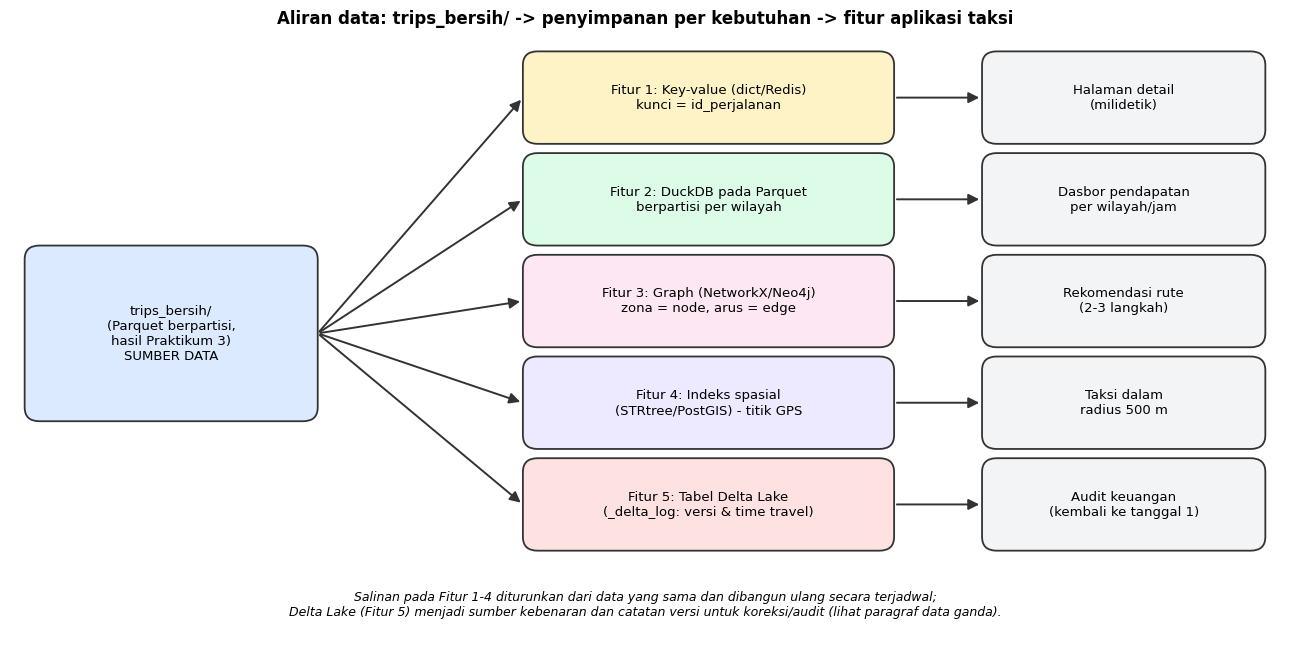

tersimpan: /content/drive/MyDrive/BigData/Praktikum4/Tugas/diagram_aliran_data.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 6.8))
ax.set_xlim(0, 13); ax.set_ylim(0, 7); ax.axis("off")

def kotak(x0, y0, lebar, tinggi, teks, warna):
    ax.add_patch(FancyBboxPatch((x0, y0), lebar, tinggi, boxstyle="round,pad=0.05,rounding_size=0.15",
                                fc=warna, ec="#333333", lw=1.3))
    ax.text(x0 + lebar / 2, y0 + tinggi / 2, teks, ha="center", va="center", fontsize=9.5)

def panah(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16, lw=1.4, color="#333333"))

# Sumber
kotak(0.2, 2.6, 2.9, 1.8, "trips_bersih/\n(Parquet berpartisi,\nhasil Praktikum 3)\nSUMBER DATA", "#dbeafe")
# Penyimpanan turunan (kolom tengah)
daftar = [
    (6.0, "Fitur 1: Key-value (dict/Redis)\nkunci = id_perjalanan", "#fef3c7"),
    (4.9, "Fitur 2: DuckDB pada Parquet\nberpartisi per wilayah", "#dcfce7"),
    (3.8, "Fitur 3: Graph (NetworkX/Neo4j)\nzona = node, arus = edge", "#fce7f3"),
    (2.7, "Fitur 4: Indeks spasial\n(STRtree/PostGIS) - titik GPS", "#ede9fe"),
    (1.6, "Fitur 5: Tabel Delta Lake\n(_delta_log: versi & time travel)", "#fee2e2"),
]
for y0, teks, warna in daftar:
    kotak(5.3, y0 - 0.4, 3.7, 0.9, teks, warna)
    panah(3.15, 3.5, 5.25, y0 + 0.05)

# Keluaran
keluaran = [(6.0, "Halaman detail\n(milidetik)"), (4.9, "Dasbor pendapatan\nper wilayah/jam"),
            (3.8, "Rekomendasi rute\n(2-3 langkah)"), (2.7, "Taksi dalam\nradius 500 m"),
            (1.6, "Audit keuangan\n(kembali ke tanggal 1)")]
for y0, teks in keluaran:
    kotak(10.0, y0 - 0.4, 2.8, 0.9, teks, "#f3f4f6")
    panah(9.05, y0 + 0.05, 9.95, y0 + 0.05)

ax.text(6.5, 6.85, "Aliran data: trips_bersih/ -> penyimpanan per kebutuhan -> fitur aplikasi taksi",
        ha="center", fontsize=12, fontweight="bold")
ax.text(6.5, 0.45, "Salinan pada Fitur 1-4 diturunkan dari data yang sama dan dibangun ulang secara terjadwal;\n"
                    "Delta Lake (Fitur 5) menjadi sumber kebenaran dan catatan versi untuk koreksi/audit (lihat paragraf data ganda).",
        ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.savefig(f"{DIR_TUGAS}/diagram_aliran_data.png", dpi=200, bbox_inches="tight")
plt.show()
print("tersimpan:", f"{DIR_TUGAS}/diagram_aliran_data.png")

### Paragraf: data yang terpaksa disimpan ganda
>

Pada rancangan ini data perjalanan yang sama terpaksa tersimpan lebih dari sekali: sebagai pasangan key-value untuk halaman detail (Fitur 1), sebagai Parquet berpartisi untuk dasbor (Fitur 2), sebagai graph arus antar zona untuk rekomendasi rute (Fitur 3), sebagai indeks spasial untuk pencarian radius (Fitur 4), dan sebagai tabel Delta untuk audit (Fitur 5). Agar salinan-salinan itu tetap sama, tabel Delta dijadikan **sumber kebenaran tunggal**: semua penulisan dan koreksi hanya dilakukan di sana, sedangkan salinan lain diperlakukan sebagai turunan yang dibangun ulang dari versi Delta tertentu (secara terjadwal atau setiap ada versi baru). Setiap salinan mencatat nomor versi Delta yang menjadi sumbernya, dan konsistensinya diperiksa dengan menyilangkan jumlah baris dan `SUM(total_bayar)` dengan tabel Delta, seperti penyilangan graph dengan SQL pada K-5. Konsekuensinya konsistensi yang dicapai bersifat *eventual*: dasbor atau rekomendasi rute bisa tertinggal sesaat setelah koreksi, yang dapat diterima untuk Fitur 2-4, tetapi tidak untuk data yang menyangkut saldo atau tagihan (sesuai teorema CAP pada materi G.2).

In [ ]:
# Menyimpan draf laporan (Markdown) agar mudah disalin ke dokumen laporan PDF
try:
    tabel_md = studi_kasus.to_markdown(index=False)
except ImportError:
    tabel_md = studi_kasus.to_string(index=False)
draf = ["# Draf Laporan Praktikum 4 - Rancangan Penyimpanan Aplikasi Taksi", "",
        "## Tabel rancangan", "", tabel_md, "",
        "## Diagram", "", "Sisipkan `diagram_aliran_data.png`.", "",
        "## Data yang disimpan ganda", "", "(Tulis paragraf Anda di sini.)"]
try:
    open(f"{DIR_TUGAS}/draf_laporan.md", "w").write("\n".join(draf))
except Exception as e:
    print("gagal menyimpan draf:", e)
print("tersimpan:", f"{DIR_TUGAS}/draf_laporan.md")

tersimpan: /content/drive/MyDrive/BigData/Praktikum4/Tugas/draf_laporan.md


### Mengarsipkan `trips_delta/` (zip)
Berkas yang dikumpulkan adalah arsip `trips_delta.zip` (tabel Delta dari notebook utama, K-7/K-8). Arsip tabel dua hari (R.3) dibuat sebagai tambahan.

In [ ]:
SUMBER_DELTA = f"{DIR_SIMPAN}/trips_delta"
if os.path.exists(SUMBER_DELTA):
    z = shutil.make_archive(f"{DIR_SIMPAN}/trips_delta", "zip", root_dir=DIR_SIMPAN, base_dir="trips_delta")
    print("arsip dibuat:", z, f"({os.path.getsize(z) / 1024**2:.1f} MB)")
else:
    print("PERINGATAN: folder trips_delta/ dari notebook utama tidak ditemukan. Jalankan notebook utama sampai K-8.")

z2 = shutil.make_archive(f"{DIR_TUGAS}/trips_delta_dua_hari", "zip", root_dir=DIR_TUGAS, base_dir="trips_delta_dua_hari")
print("arsip tambahan (R.3):", z2)

print("\nIsi folder Tugas:")
for f in sorted(os.listdir(DIR_TUGAS)):
    print(" -", f)

arsip dibuat: /content/drive/MyDrive/BigData/Praktikum4/trips_delta.zip (3.7 MB)
arsip tambahan (R.3): /content/drive/MyDrive/BigData/Praktikum4/Tugas/trips_delta_dua_hari.zip

Isi folder Tugas:
 - diagram_aliran_data.png
 - draf_laporan.md
 - isi_delta_log_dua_hari.txt
 - rancangan_data_lain.csv
 - rekap_k9_terisi.csv
 - tabel_studi_kasus.csv
 - trips_delta_dua_hari
 - trips_delta_dua_hari.zip
